In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from time import perf_counter

from solver import mrSAV_Vorticity_Stream_Periodic_Solve as msSolver

Path("fig").mkdir(exist_ok=True)

_texbin = Path("/Library/TeX/texbin")
if _texbin.exists() and str(_texbin) not in os.environ.get("PATH", "").split(os.pathsep):
    os.environ["PATH"] = f"{_texbin}{os.pathsep}{os.environ.get('PATH', '')}"

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.family": "Time New Roman",
    "font.size": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

# Convergence test for mrSAV-ETDMS

## Fix Stepsize (Comparison for different mr-SAV scheme)

In [3]:
nu = 1/1000
gam = 1000

s_domain = (0,0, 2*np.pi, 2*np.pi)
discrete_num = [128, 128]

xn = np.linspace(s_domain[0],s_domain[2],discrete_num[0]+1)
yn = np.linspace(s_domain[1],s_domain[3],discrete_num[1]+1)
X,Y = np.meshgrid(xn,yn)

t_period = (0, 1)
delta = 0.01

def tau_sequence_to_T(t_span, tau):
    T0, T = t_span
    length = T - T0
    n_full = int(np.floor(length / tau))
    taus = np.full(n_full, tau, dtype=float)
    remain = T - (T0 + n_full * tau)
    tol = 100*np.finfo(float).eps*max(1.0, abs(T0), abs(T))
    if len(taus) == 0:
        taus = np.array([length], dtype=float)
    elif remain > tol:
        taus = np.r_[taus, remain]
    else:
        taus[-1] += remain
    return taus

def fixed_step_err_test(nu,gam,start,end,step_method,initial_data,force_term,reference_data,levels=None,taus=None):
    ref_solution_omega = reference_data["omega"]
    ref_solution_psi = reference_data["psi"]
    ref_solution_u = reference_data["u"]
    ref_solution_v = reference_data["v"]
    
    err_omega = []
    err_psi = []
    err_u = []
    err_q = []
    err_cpu = []
    if taus is None:
        if levels is None:
            levels = range(start, end + 1)
        taus = delta * 2**(-np.asarray(levels, dtype=float))
    for tau in np.asarray(taus, dtype=float):
        solver = msSolver(nu,gam,s_domain,discrete_num,initial_data,force_term,step_method)
        cpu_start = perf_counter()
        solver.solve_fix_step(t_period, float(tau))
        err_cpu.append(perf_counter() - cpu_start)
        Omege = solver.Omega[-1]
        Psi = solver.vorticity2stream(Omege)
        u,v = solver.stream2velocity(Psi)
        q = solver.q[-1]

        err_omega.append(np.sqrt(solver.h*np.mean(np.square(Omege - ref_solution_omega))))
        err_psi.append(np.sqrt(solver.h*np.mean(np.square(Psi - ref_solution_psi))))
        err_u.append(np.sqrt(solver.h*np.mean(np.square(u - ref_solution_u)) + solver.h*np.mean(np.square(v - ref_solution_v))))
        err_q.append((np.abs(q - 1)))
    return err_omega,err_psi,err_u,err_q,err_cpu

In [4]:
def smooth_trig_initial_vorticity(X, Y, K=10, amplitude=1.0, seed=0):
    rng = np.random.default_rng(seed)
    omega = np.zeros_like(X)

    for k in range(1, K + 1):
        for m in range(1, K + 1):
            coeff = (k*k + m*m)**(-3/2)
            omega += coeff * np.cos(k*X) * np.cos(m*Y)

    omega -= np.mean(omega[:-1, :-1])
    omega *= amplitude / np.sqrt(np.mean(omega[:-1, :-1]**2))
    return omega

initial_vorticity = smooth_trig_initial_vorticity(X, Y, K=10, amplitude=1.0, seed=0)

def force_term(X, Y, t):
    f = np.cos(X)
    return f

In [4]:
tau_ref = delta*2**-8
solver_ref = msSolver(nu, gam,s_domain, discrete_num, initial_vorticity, force_term, "ETDRK4")
solver_ref.solve_fix_step(t_period,tau_ref)
ref_solution_omega = solver_ref.Omega[-1]
ref_solution_psi = solver_ref.vorticity2stream(ref_solution_omega)
ref_u, ref_v = solver_ref.stream2velocity(ref_solution_psi)

reference_data = {
    "omega": ref_solution_omega,
    "psi": ref_solution_psi,
    "u": ref_u,
    "v": ref_v
}

 1.000000\1, Elapse: 0.005 s, Vorticity Energy:18.8368, Energy rate:2.0109e+01, Enstrophy:29.6237, Enstrophy rate:2.0029e+01, Palinstrophy:69.7343, Maximum:5.75, |q-1|:0.0000e+00      


In [5]:
start,end = 0,8
fixed_step_levels = np.array([0.,1.,2.,3.,4.,5.,6.,7.,8.])
fixed_step_taus = delta * 2**(-fixed_step_levels)

step_method = "SDIRK2_mr_SAV"
print(step_method)
err_sdirk2_mrsav = fixed_step_err_test(nu,gam,start,end,step_method,initial_vorticity,force_term,reference_data,taus=fixed_step_taus)

step_method = "ETD_mrSAV_MS2_b"
print(step_method)
err_etd_mrgsav_ms2 = fixed_step_err_test(nu,gam,start,end,step_method,initial_vorticity,force_term,reference_data,taus=fixed_step_taus)

step_method = "ETD_mrSAV_MS2_L"
print(step_method)
err_etd_mrsav_ms2_l = fixed_step_err_test(nu,gam,start,end,step_method,initial_vorticity,force_term,reference_data,taus=fixed_step_taus)

step_method = "mr_SAV_BDF2"
print(step_method)
err_bdf_mrsav_ms2 = fixed_step_err_test(nu,gam,start,end,step_method,initial_vorticity,force_term,reference_data,taus=fixed_step_taus)

SDIRK2_mr_SAV
 1.000000\1, Elapse: 0.003 s, Vorticity Energy:18.8369, Energy rate:2.0109e+01, Enstrophy:29.6239, Enstrophy rate:2.0029e+01, Palinstrophy:69.7416, Maximum:5.75, |q-1|:3.4071e-05     
 1.000000\1, Elapse: 0.003 s, Vorticity Energy:18.8369, Energy rate:2.0109e+01, Enstrophy:29.6238, Enstrophy rate:2.0029e+01, Palinstrophy:69.7360, Maximum:5.75, |q-1|:1.6781e-05     
 1.000000\1, Elapse: 0.003 s, Vorticity Energy:18.8369, Energy rate:2.0109e+01, Enstrophy:29.6237, Enstrophy rate:2.0029e+01, Palinstrophy:69.7348, Maximum:5.75, |q-1|:8.3459e-06     
 1.000000\1, Elapse: 0.003 s, Vorticity Energy:18.8368, Energy rate:2.0109e+01, Enstrophy:29.6237, Enstrophy rate:2.0029e+01, Palinstrophy:69.7344, Maximum:5.75, |q-1|:4.1649e-06      
 1.000000\1, Elapse: 0.003 s, Vorticity Energy:18.8368, Energy rate:2.0109e+01, Enstrophy:29.6237, Enstrophy rate:2.0029e+01, Palinstrophy:69.7344, Maximum:5.75, |q-1|:2.0809e-06      
 1.000000\1, Elapse: 0.003 s, Vorticity Energy:18.8368, Energy r

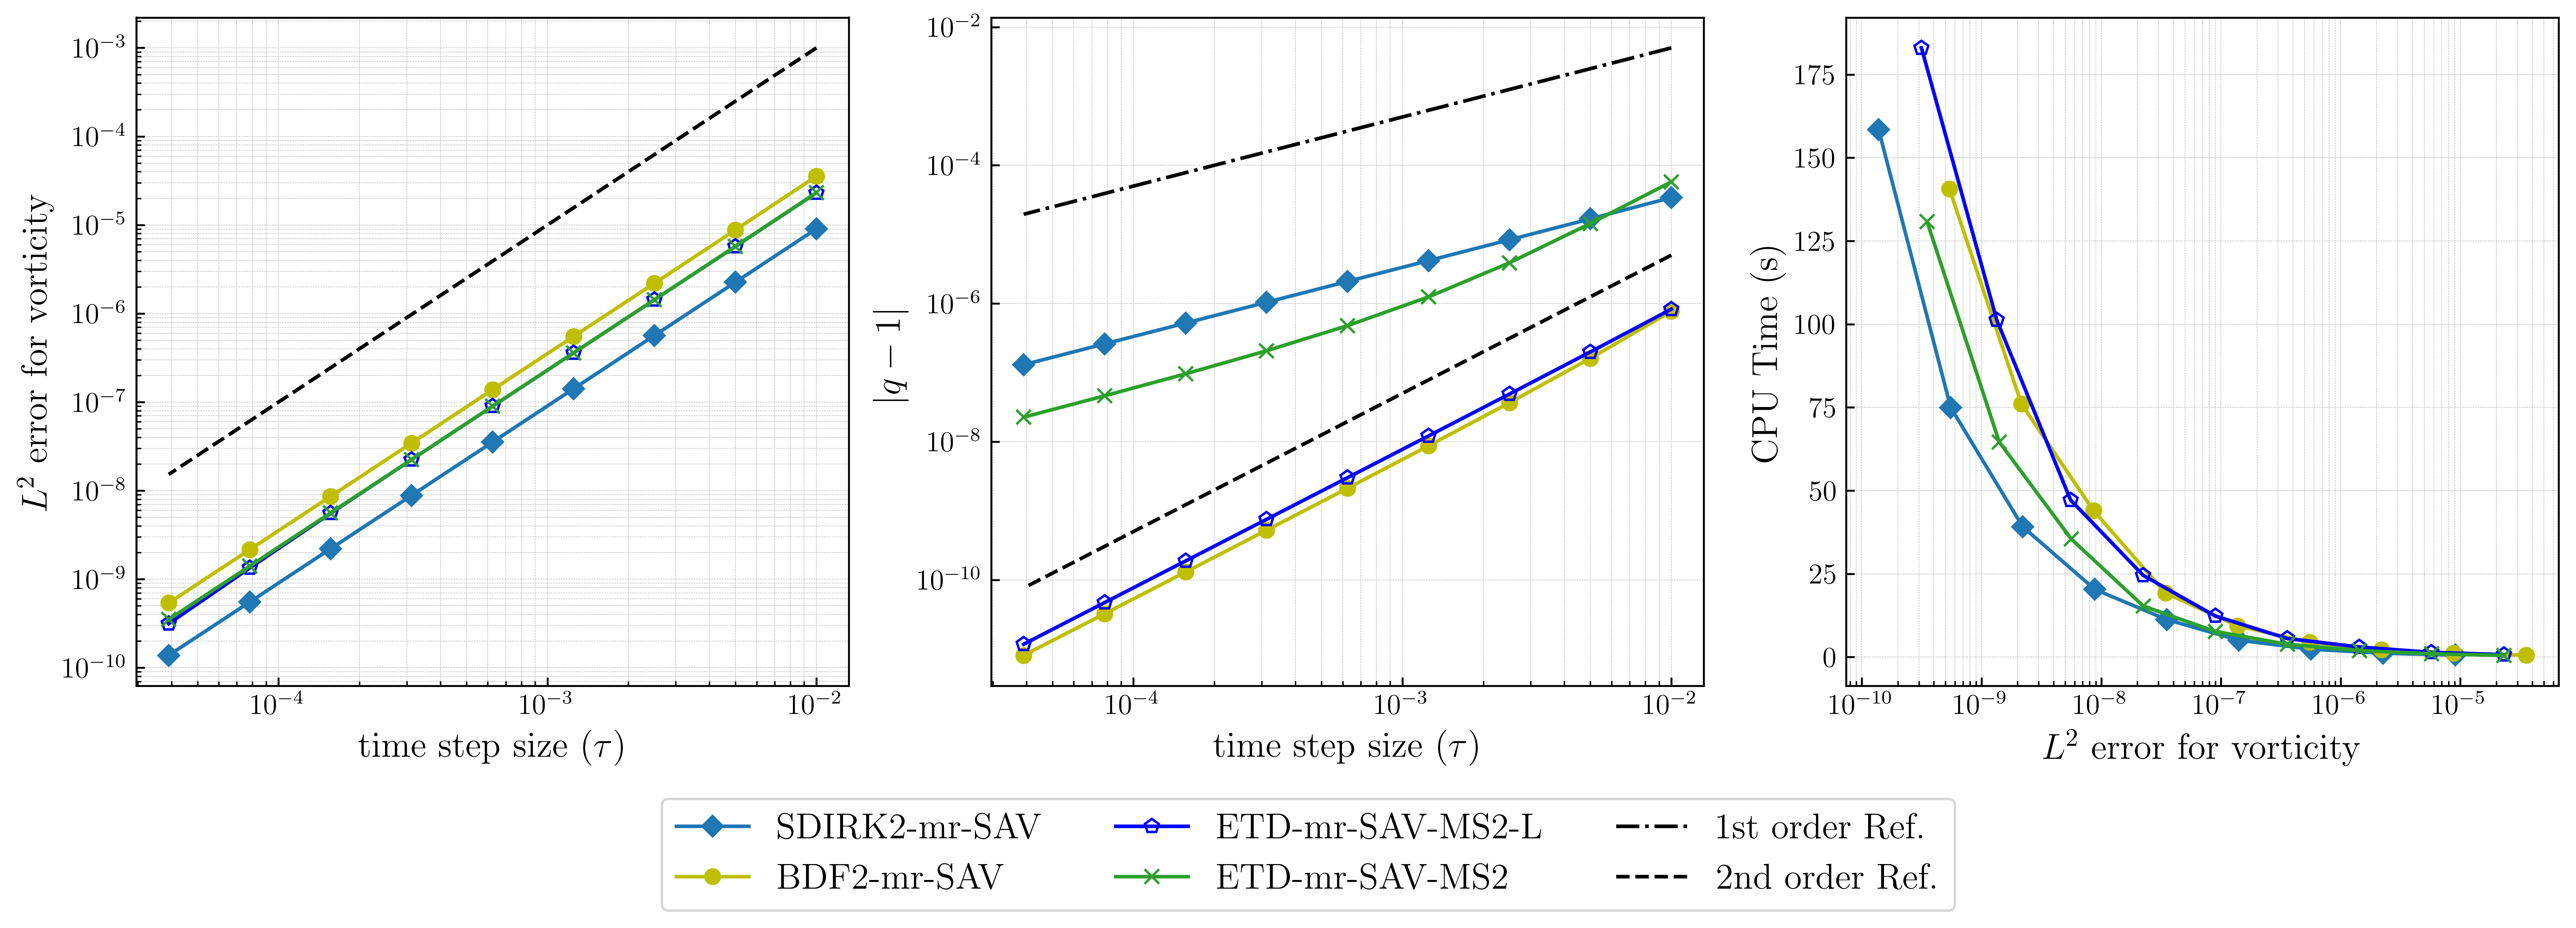

In [6]:
fig = plt.figure(figsize=(18,5),dpi=600)

plt.subplot(1,3,1)
plt.plot(fixed_step_taus, err_sdirk2_mrsav[0], "C0-",marker = "D", fillstyle ="full",  label=r"SDIRK2-mr-SAV")
plt.plot(fixed_step_taus, err_bdf_mrsav_ms2[0],"y-",marker = "o", fillstyle ="full",  label=r"BDF2-mr-SAV")
plt.plot(fixed_step_taus, err_etd_mrsav_ms2_l[0],"b-", marker = "p",fillstyle ="none", label=r"ETD-mr-SAV-MS2-L")
plt.plot(fixed_step_taus, err_etd_mrgsav_ms2[0],"C2-",marker = "x",fillstyle ="none", label=r"ETD-mr-SAV-MS2")
plt.plot(fixed_step_taus, 1e-3*(fixed_step_taus/delta)**2,"k--")

plt.xscale("log")
plt.yscale("log")
plt.grid(which="both", linestyle='--', linewidth=0.2)

plt.ylabel(r"$L^{2}$ error for vorticity",fontsize = 15)
plt.xlabel(r"time step size ($\tau$)",fontsize = 15)

plt.subplot(1,3,2)
plt.plot(fixed_step_taus, err_sdirk2_mrsav[3], "C0-", marker  = "D", fillstyle ="full")
plt.plot(fixed_step_taus, err_bdf_mrsav_ms2[3], "y-", marker  = "o", fillstyle ="full")
plt.plot(fixed_step_taus, err_etd_mrsav_ms2_l[3],"b-", marker  = "p",fillstyle ="none")
plt.plot(fixed_step_taus, err_etd_mrgsav_ms2[3],"C2-",marker = "x" ,fillstyle ="none")
plt.plot(fixed_step_taus, 5e-3*(fixed_step_taus/delta),"k-.",  label="1st order Ref.")
plt.plot(fixed_step_taus, 5e-6*(fixed_step_taus/delta)**2,"k--", label="2nd order Ref.")
plt.grid(which="both", linestyle='--', linewidth=0.2)

plt.xscale("log")
plt.yscale("log")
# plt.xlim(5e-4,5e-1)
# plt.ylim(5e-9,1e-3)
plt.ylabel(r"$|q-1|$",fontsize = 15)
plt.xlabel(r"time step size ($\tau$)",fontsize = 15)

plt.subplot(1,3,3)
plt.plot(err_sdirk2_mrsav[0],    err_sdirk2_mrsav[4], "C0-", marker = "D", fillstyle ="full")
plt.plot(err_bdf_mrsav_ms2[0],   err_bdf_mrsav_ms2[4],  "y-", marker="o", fillstyle="full")
plt.plot(err_etd_mrsav_ms2_l[0], err_etd_mrsav_ms2_l[4],"b-", marker="p", fillstyle="none")
plt.plot(err_etd_mrgsav_ms2[0],  err_etd_mrgsav_ms2[4],  "C2-", marker="x", fillstyle="none")
plt.xscale("log")
# plt.yscale("log")
plt.grid(which="both", linestyle="--", linewidth=0.2)

plt.ylabel(r"CPU Time (s)",fontsize = 15)
plt.xlabel(r"$L^{2}$ error for vorticity",fontsize = 15)


plt.figlegend(loc="lower center",ncol = 3, fontsize = 15, bbox_to_anchor = [0.5,-0.17])
# plt.savefig("fig/conv_test_compare_lap.pdf", dpi=600, bbox_inches = "tight", pad_inches = 0.2)
plt.show()

In [7]:
def _latex_sci(x, digits=3):
    if not np.isfinite(x):
        return "--"
    if x == 0:
        return "0"
    exponent = int(np.floor(np.log10(abs(x))))
    mantissa = x / 10**exponent
    return rf"${mantissa:.{digits}f}\times 10^{{{exponent}}}$"


def _orders(errors, taus=None):
    errors = np.asarray(errors, dtype=float)
    out = [np.nan]
    if taus is None:
        ratios = np.full(len(errors) - 1, 2.0, dtype=float)
    else:
        taus = np.asarray(taus, dtype=float)
        ratios = taus[:-1] / taus[1:]
    for j in range(1, len(errors)):
        if errors[j-1] > 0 and errors[j] > 0:
            out.append(np.log(errors[j-1] / errors[j]) / np.log(ratios[j-1]))
        else:
            out.append(np.nan)
    return np.asarray(out)


def _latex_order(x):
    return "--" if not np.isfinite(x) else f"{x:.2f}"


def _latex_k_level(k):
    k = float(k)
    if k.is_integer():
        return str(int(k))
    return f"{k:.1f}".rstrip("0").rstrip(".")


def make_fixed_step_latex_table(filename="fixed_step_convergence_table.tex"):
    indices = np.asarray(fixed_step_levels, dtype=float)
    methods = [
        (r"SDIRK2_mr_SAV", err_sdirk2_mrsav),
        (r"BDF2-mr-SAV", err_bdf_mrsav_ms2),
        (r"ETD-mr-SAV-MS2", err_etd_mrgsav_ms2),
        (r"ETD-mr-SAV-MS2-L", err_etd_mrsav_ms2_l),
    ]

    method_data = []
    for method_name, err in methods:
        omega_err = np.asarray(err[0], dtype=float)
        cpu_time = np.asarray(err[4], dtype=float)
        omega_order = _orders(omega_err, fixed_step_taus)
        method_data.append((method_name, omega_err, omega_order, cpu_time))

    lines = []
    lines.append(r"\begin{table}[htbp]")
    lines.append(r"\centering")
    lines.append(rf"\caption{{Vorticity $L^2$ errors, observed convergence rates, and CPU times for the tested schemes at $T=1$ under nominal fixed time stepping, with the final step clipped to hit $T$ exactly when needed. Here $k$ is defined by $\tau={delta:g}\times 2^{{-k}}$.}}")
    lines.append(r"\label{tab:fixed-step-convergence-cpu}")
    lines.append(r"\resizebox{\textwidth}{!}{%")
    lines.append(r"\begin{tabular}{c" + "ccc" * len(methods) + r"}")
    lines.append(r"\toprule")
    header = [r"$k$"]
    for method_name, *_ in method_data:
        header.append(rf"\multicolumn{{3}}{{c}}{{{method_name}}}")
    lines.append(" & ".join(header) + r" \\")
    cmidrules = []
    for k in range(len(methods)):
        start_col = 2 + 3*k
        end_col = start_col + 2
        cmidrules.append(rf"\cmidrule(lr){{{start_col}-{end_col}}}")
    lines.append(" ".join(cmidrules))
    subheader = [""]
    for _ in method_data:
        subheader.extend([r"Error", r"Order", r"CPU (s)"])
    lines.append(" & ".join(subheader) + r" \\")
    lines.append(r"\midrule")

    for j, k in enumerate(indices):
        row = [_latex_k_level(k)]
        for _, omega_err, omega_order, cpu_time in method_data:
            row.extend([
                _latex_sci(omega_err[j]),
                _latex_order(omega_order[j]),
                f"{cpu_time[j]:.2f}",
            ])
        lines.append(" & ".join(row) + r" \\")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}%")
    lines.append(r"}")
    lines.append(r"\end{table}")

    table = "\n".join(lines)
    print(table)
    with open(filename, "w") as f:
        f.write(table + "\n")
    print(f"\nLaTeX table written to {filename}")
    return table


fixed_step_latex_table = make_fixed_step_latex_table()


\begin{table}[htbp]
\centering
\caption{Vorticity $L^2$ errors, observed convergence rates, and CPU times for the tested schemes at $T=1$ under nominal fixed time stepping, with the final step clipped to hit $T$ exactly when needed. Here $k$ is defined by $\tau=0.01\times 2^{-k}$.}
\label{tab:fixed-step-convergence-cpu}
\resizebox{\textwidth}{!}{%
\begin{tabular}{ccccccccccccc}
\toprule
$k$ & \multicolumn{3}{c}{SDIRK2_mr_SAV} & \multicolumn{3}{c}{BDF2-mr-SAV} & \multicolumn{3}{c}{ETD-mr-SAV-MS2} & \multicolumn{3}{c}{ETD-mr-SAV-MS2-L} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7} \cmidrule(lr){8-10} \cmidrule(lr){11-13}
 & Error & Order & CPU (s) & Error & Order & CPU (s) & Error & Order & CPU (s) & Error & Order & CPU (s) \\
\midrule
0 & $9.061\times 10^{-6}$ & -- & 0.61 & $3.555\times 10^{-5}$ & -- & 0.58 & $2.319\times 10^{-5}$ & -- & 0.52 & $2.308\times 10^{-5}$ & -- & 0.73 \\
1 & $2.262\times 10^{-6}$ & 2.00 & 1.15 & $8.798\times 10^{-6}$ & 2.01 & 1.20 & $5.741\times 10^{-6}$ & 2.01 & 1

## Fix Stepsize (Comparison for original SDIRK2 and SDIRK2-mr-SAV scheme)

In [8]:
import contextlib
import io
import warnings

# 1. Parameters and ETDRK4 reference data
# Reproduce the fixed-step SDIRK2 comparison in Table~\ref{tab:sdirk2-fixed-convergence}.
# The existing nu, gam, domain, grid, initial_vorticity, and force_term are reused.
sdirk_levels = np.array([1.0, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])
sdirk_delta = 0.1
sdirk_taus = sdirk_delta * 2.0**(-sdirk_levels)
sdirk_times = np.array([1.0, 1.5, 2.0])
sdirk_tau_ref = sdirk_delta * 2.0**(-8)


def _tau_segment_to_target(t_start, t_target, nominal_tau):
    length = float(t_target - t_start)
    nominal_tau = float(nominal_tau)
    n_full = int(np.floor(length / nominal_tau))
    steps = np.full(n_full, nominal_tau, dtype=float)
    remainder = length - np.sum(steps)
    tolerance = 100 * np.finfo(float).eps * max(1.0, abs(t_start), abs(t_target))

    if len(steps) == 0:
        steps = np.array([length], dtype=float)
    elif remainder > tolerance:
        steps = np.r_[steps, remainder]
    else:
        steps[-1] += remainder

    # Remove accumulated roundoff so that the segment endpoint is exact.
    steps[-1] += length - np.sum(steps)
    if np.any(steps <= 0):
        raise ValueError("The clipped time-step sequence contains a non-positive step.")
    return steps


def _sdirk_tau_sequence(nominal_tau):
    targets = np.asarray(sdirk_times, dtype=float)
    if targets.ndim != 1 or len(targets) == 0:
        raise ValueError("sdirk_times must be a non-empty one-dimensional array.")
    if targets[0] <= 0 or np.any(np.diff(targets) <= 0):
        raise ValueError("sdirk_times must be positive and strictly increasing.")
    starts = np.r_[0.0, targets[:-1]]
    return np.concatenate([
        _tau_segment_to_target(t_start, t_target, nominal_tau)
        for t_start, t_target in zip(starts, targets)
    ])


def _solve_sdirk_snapshots(step_method, tau):
    solver = msSolver(
        nu, gam, s_domain, discrete_num,
        initial_vorticity, force_term, step_method,
    )
    # Suppress per-step diagnostics; the compact summary below reports stability.
    with warnings.catch_warnings(), contextlib.redirect_stdout(io.StringIO()):
        warnings.simplefilter("ignore", RuntimeWarning)
        solver.solve_given_tau(
            (0.0, float(sdirk_times[-1])),
            _sdirk_tau_sequence(tau),
            snapshot=sdirk_times,
        )
    return solver, np.asarray(solver.Omega, dtype=float)


def _vorticity_l2_error(omega, omega_ref, cell_area):
    difference = np.asarray(omega) - np.asarray(omega_ref)
    if not np.all(np.isfinite(difference)):
        return np.nan
    return float(np.sqrt(cell_area * np.sum(difference**2)))


print(f"Computing ETDRK4 reference: tau_ref = {sdirk_tau_ref:.9g}")
sdirk_reference_solver, sdirk_reference_omega = _solve_sdirk_snapshots(
    "ETDRK4", sdirk_tau_ref,
)

Computing ETDRK4 reference: tau_ref = 0.000390625


In [9]:
# 2. Generate errors and observed convergence rates

sdirk_methods = [
    ("SDIRK2", "IMEX_RK2"),
    ("SDIRK2-mr-SAV", "SDIRK2_mr_SAV"),
]
sdirk_errors = {
    label: np.full((len(sdirk_levels), len(sdirk_times)), np.nan)
    for label, _ in sdirk_methods
}

for label, step_method in sdirk_methods:
    print(f"\n{label} ({step_method})")
    for row, (k, tau) in enumerate(zip(sdirk_levels, sdirk_taus)):
        try:
            solver, omega_at_times = _solve_sdirk_snapshots(step_method, tau)
            for column in range(len(sdirk_times)):
                sdirk_errors[label][row, column] = _vorticity_l2_error(
                    omega_at_times[column],
                    sdirk_reference_omega[column],
                    solver.h,
                )
        except (FloatingPointError, OverflowError, RuntimeError, ValueError) as exc:
            print(f"  k={k}: failed ({type(exc).__name__}: {exc})")
            continue

        status = ", ".join(
            f"T={T:g}: {error:.4e}" if np.isfinite(error) else f"T={T:g}: NaN"
            for T, error in zip(sdirk_times, sdirk_errors[label][row])
        )
        last_step_ratio = _tau_segment_to_target(0.0, 1.0, tau)[-1] / tau
        print(
            f"  k={k:g}, tau={tau:.9g}, last/tau={last_step_ratio:.3f}: {status}"
        )


def _sdirk_rates(errors, levels):
    errors = np.asarray(errors, dtype=float)
    levels = np.asarray(levels, dtype=float)
    rates = np.full_like(errors, np.nan)
    valid = (
        np.isfinite(errors[:-1]) & (errors[:-1] > 0)
        & np.isfinite(errors[1:]) & (errors[1:] > 0)
    )
    delta_k = np.diff(levels)
    rates[1:][valid] = (
        np.log2(errors[:-1][valid] / errors[1:][valid]) / delta_k[valid]
    )
    return rates


sdirk_rates = {
    label: np.column_stack([
        _sdirk_rates(sdirk_errors[label][:, column], sdirk_levels)
        for column in range(len(sdirk_times))
    ])
    for label, _ in sdirk_methods
}


SDIRK2 (IMEX_RK2)
  k=1, tau=0.05, last/tau=1.000: T=1: 1.9508e+00, T=1.5: NaN, T=2: NaN
  k=2, tau=0.025, last/tau=1.000: T=1: 7.4386e-03, T=1.5: 5.6537e+01, T=2: NaN
  k=2.2, tau=0.0217637641, last/tau=0.948: T=1: 5.5564e-03, T=1.5: 2.3969e-01, T=2: NaN
  k=2.4, tau=0.0189464571, last/tau=0.780: T=1: 4.1471e-03, T=1.5: 1.2261e-02, T=2: NaN
  k=2.6, tau=0.0164938489, last/tau=0.629: T=1: 3.1264e-03, T=1.5: 9.1135e-03, T=2: 3.8316e+00
  k=2.8, tau=0.0143587294, last/tau=0.644: T=1: 2.3681e-03, T=1.5: 6.8419e-03, T=2: 1.8901e-02
  k=3, tau=0.0125, last/tau=1.000: T=1: 1.8154e-03, T=1.5: 5.2134e-03, T=2: 1.3509e-02
  k=4, tau=0.00625, last/tau=1.000: T=1: 4.5242e-04, T=1.5: 1.2845e-03, T=2: 3.2193e-03
  k=5, tau=0.003125, last/tau=1.000: T=1: 1.1307e-04, T=1.5: 3.2038e-04, T=2: 7.9958e-04
  k=6, tau=0.0015625, last/tau=1.000: T=1: 2.8270e-05, T=1.5: 8.0059e-05, T=2: 1.9967e-04
  k=7, tau=0.00078125, last/tau=1.000: T=1: 7.0680e-06, T=1.5: 2.0013e-05, T=2: 4.9904e-05
  k=8, tau=0.0003906

In [10]:
# 3. Generate the LaTeX table

def _sdirk_latex_error(value):
    if not np.isfinite(value):
        return r"\texttt{NaN}"
    if value == 0:
        return r"$0$"
    exponent = int(np.floor(np.log10(abs(value))))
    mantissa = value / 10.0**exponent
    return rf"${mantissa:.4f}\times10^{{{exponent}}}$"


def _sdirk_latex_rate(value, expected_order=2.0, tolerance=0.25):
    if not np.isfinite(value):
        return "--"
    if abs(value - expected_order) > tolerance:
        return r"\texttt{pre-asymp}"
    return f"{value:.2f}"


def _sdirk_latex_level(value):
    value = float(value)
    return str(int(value)) if value.is_integer() else f"{value:.1f}"


def make_sdirk2_fixed_convergence_table(
    filename="sdirk2_fixed_convergence_table.tex",
):
    time_labels = [f"T={T:g}" for T in sdirk_times]
    time_list = ", ".join(f"${label}$" for label in time_labels)
    column_spec = "l " + " ".join(["cc cc"] * len(sdirk_times))
    time_header = "& " + " & ".join(
        rf"\multicolumn{{4}}{{c}}{{${label}$}}" for label in time_labels
    ) + r"\\"
    time_rules = "".join(
        rf"\cmidrule(lr){{{2 + 4 * column}-{5 + 4 * column}}}"
        for column in range(len(sdirk_times))
    )
    method_header = "& " + " & ".join(
        [r"\multicolumn{2}{c}{SDIRK2}", r"\multicolumn{2}{c}{SDIRK2-mr-SAV}"]
        * len(sdirk_times)
    ) + r"\\"
    method_rules = "".join(
        rf"\cmidrule(lr){{{start}-{start + 1}}}"
        for start in range(2, 2 + 4 * len(sdirk_times), 2)
    )
    column_header = "$k$ & " + " & ".join(
        ["Error & Rate & Error & Rate"] * len(sdirk_times)
    ) + r"\\"

    lines = [
        r"\begin{table}",
        r"\centering",
        rf"\caption{{Vorticity $L^2$ errors and observed convergence rates at {time_list}.",
        r"The reference solution is computed by ETDRK4 with",
        r"$\tau_{\rm ref}=0.1\times2^{-8}$. The time steps are given by",
        r"$\tau=0.1\times2^{-k}$, with additional levels $k=2.2,2.4,2.6,2.8$.}",
        r"\label{tab:sdirk2-fixed-convergence}",
        r"\setlength{\tabcolsep}{4pt}",
        r"\resizebox{\textwidth}{!}{",
        rf"\begin{{tabular}}{{{column_spec}}}",
        r"\toprule",
        time_header,
        time_rules,
        method_header,
        method_rules,
        column_header,
        r"\midrule",
    ]

    for row, k in enumerate(sdirk_levels):
        entries = [_sdirk_latex_level(k)]
        for column in range(len(sdirk_times)):
            for label, _ in sdirk_methods:
                entries.extend([
                    _sdirk_latex_error(sdirk_errors[label][row, column]),
                    _sdirk_latex_rate(sdirk_rates[label][row, column]),
                ])
        lines.append(" & ".join(entries) + r" \\")

    lines.extend([
        r"\bottomrule",
        r"\end{tabular}}",
        r"\end{table}",
    ])
    table = "\n".join(lines)
    Path(filename).write_text(table + "\n", encoding="utf-8")
    print(f"\nLaTeX table written to {filename}\n")
    print(table)
    return table


sdirk2_fixed_convergence_table = make_sdirk2_fixed_convergence_table()


LaTeX table written to sdirk2_fixed_convergence_table.tex

\begin{table}
\centering
\caption{Vorticity $L^2$ errors and observed convergence rates at $T=1$, $T=1.5$, $T=2$.
The reference solution is computed by ETDRK4 with
$\tau_{\rm ref}=0.1\times2^{-8}$. The time steps are given by
$\tau=0.1\times2^{-k}$, with additional levels $k=2.2,2.4,2.6,2.8$.}
\label{tab:sdirk2-fixed-convergence}
\setlength{\tabcolsep}{4pt}
\resizebox{\textwidth}{!}{
\begin{tabular}{l cc cc cc cc cc cc}
\toprule
& \multicolumn{4}{c}{$T=1$} & \multicolumn{4}{c}{$T=1.5$} & \multicolumn{4}{c}{$T=2$}\\
\cmidrule(lr){2-5}\cmidrule(lr){6-9}\cmidrule(lr){10-13}
& \multicolumn{2}{c}{SDIRK2} & \multicolumn{2}{c}{SDIRK2-mr-SAV} & \multicolumn{2}{c}{SDIRK2} & \multicolumn{2}{c}{SDIRK2-mr-SAV} & \multicolumn{2}{c}{SDIRK2} & \multicolumn{2}{c}{SDIRK2-mr-SAV}\\
\cmidrule(lr){2-3}\cmidrule(lr){4-5}\cmidrule(lr){6-7}\cmidrule(lr){8-9}\cmidrule(lr){10-11}\cmidrule(lr){12-13}
$k$ & Error & Rate & Error & Rate & Error & Rate & E

## Variable Stepsize

In [11]:
nu = 1/1000
gam = 1000

s_domain = (0,0, 2*np.pi, 2*np.pi)
discrete_num = [256,256]
xn = np.linspace(s_domain[0],s_domain[2],discrete_num[0]+1)
yn = np.linspace(s_domain[1],s_domain[3],discrete_num[1]+1)
X,Y = np.meshgrid(xn,yn)

t_period = (0, 1)
delta = 0.1

def err_test(nu,gam,start,end,step_method,initial_data,force_term,reference_data):
    ref_solution_omega = reference_data["omega"]
    ref_solution_psi = reference_data["psi"]
    ref_solution_u = reference_data["u"]
    ref_solution_v = reference_data["v"]
    
    err_omega = []
    err_psi = []
    err_u = []
    err_q = []
    err_cpu = []
    for i in range(start,end+1):
        solver = msSolver(nu,gam,s_domain,discrete_num,initial_data,force_term,step_method)
        N = 10*2**i
        perb = np.random.uniform(-1,1,N); perb = perb - np.mean(perb)
        tau = 1/N + 0.15*1/N*perb

        cpu_start = perf_counter()
        solver.solve_given_tau(t_period, tau)
        err_cpu.append(perf_counter() - cpu_start)
        Omege = solver.Omega[-1]
        Psi = solver.vorticity2stream(Omege)
        u,v = solver.stream2velocity(Psi)
        q = solver.q[-1]

        err_omega.append(np.sqrt(solver.h*np.mean(np.square(Omege - ref_solution_omega))))
        err_psi.append(np.sqrt(solver.h*np.mean(np.square(Psi - ref_solution_psi))))
        err_u.append(np.sqrt(solver.h*np.mean(np.square(u - ref_solution_u)) + solver.h*np.mean(np.square(v - ref_solution_v))))
        err_q.append((np.abs(q - 1)))
    return err_omega,err_psi,err_u,err_q,err_cpu


In [12]:
initial_vorticity = smooth_trig_initial_vorticity(X, Y, K=10, amplitude=1.0, seed=0)

def force_term(X, Y, t):
    f = np.cos(X)
    return f

tau_ref = delta*2**-10
solver_ref = msSolver(nu, gam, s_domain, discrete_num, initial_vorticity, force_term, "ETDRK4")
solver_ref.solve_fix_step(t_period,tau_ref)
ref_solution_omega = solver_ref.Omega[-1]
ref_solution_psi = solver_ref.vorticity2stream(ref_solution_omega)
ref_u, ref_v = solver_ref.stream2velocity(ref_solution_psi)

reference_data = {
    "omega": ref_solution_omega,
    "psi": ref_solution_psi,
    "u": ref_u,
    "v": ref_v
}

 1.000000\1, Elapse: 0.022 s, Vorticity Energy:18.8368, Energy rate:2.0109e+01, Enstrophy:29.6237, Enstrophy rate:2.0029e+01, Palinstrophy:69.7343, Maximum:5.75, |q-1|:0.0000e+00      


In [13]:
start,end = 4,11

step_method = "SDIRK2_mr_SAV"
print(step_method)
err_sdirk2_mrsav = err_test(nu,gam,start,end,step_method,initial_vorticity,force_term,reference_data)

SDIRK2_mr_SAV
 1.000000\1.0, tau = 0.006470, Elapse: 0.013 s, Vorticity Energy:18.8369, Energy rate:2.0109e+01, Enstrophy:29.6238, Enstrophy rate:2.0029e+01, Palinstrophy:69.7371, Maximum:5.75, |q-1|:2.2361e-05     
 1.000000\1.0, tau = 0.002761, Elapse: 0.014 s, Vorticity Energy:18.8369, Energy rate:2.0109e+01, Enstrophy:29.6237, Enstrophy rate:2.0029e+01, Palinstrophy:69.7350, Maximum:5.75, |q-1|:9.2393e-06     
 1.000000\1.0, tau = 0.001331, Elapse: 0.012 s, Vorticity Energy:18.8368, Energy rate:2.0109e+01, Enstrophy:29.6237, Enstrophy rate:2.0029e+01, Palinstrophy:69.7345, Maximum:5.75, |q-1|:4.6839e-06     
 1.000000\1.0, tau = 0.000853, Elapse: 0.013 s, Vorticity Energy:18.8368, Energy rate:2.0109e+01, Enstrophy:29.6237, Enstrophy rate:2.0029e+01, Palinstrophy:69.7344, Maximum:5.75, |q-1|:2.7636e-06      
 1.000000\1.0, tau = 0.000372, Elapse: 0.014 s, Vorticity Energy:18.8368, Energy rate:2.0109e+01, Enstrophy:29.6237, Enstrophy rate:2.0029e+01, Palinstrophy:69.7343, Maximum:5.7

In [14]:
def _latex_e_notation(x, digits=3):
    if not np.isfinite(x):
        return "--"
    if x == 0:
        return "0"
    mantissa, exponent = f"{x:.{digits}e}".split("e")
    exponent = int(exponent)
    sign = "+" if exponent >= 0 else ""
    return f"{mantissa}e{sign}{exponent}"


def _orders_base2(errors):
    errors = np.asarray(errors, dtype=float)
    orders = [np.nan]
    for j in range(1, len(errors)):
        if errors[j - 1] > 0 and errors[j] > 0:
            orders.append(np.log(errors[j - 1] / errors[j]) / np.log(2))
        else:
            orders.append(np.nan)
    return np.asarray(orders)


def _latex_rate(x, pre_asymp_threshold=3.0):
    if not np.isfinite(x):
        return "--"
    if x < 0 or x > pre_asymp_threshold:
        return r"\texttt{pre-asymp}"
    return f"{x:.2f}"


def make_variable_step_etd_mrsav_ms2_l_table(
    filename="variable_step_etd_mrsav_ms2_l_table.tex",
):
    errors = np.asarray(err_sdirk2_mrsav[0], dtype=float)
    rates = _orders_base2(errors)
    indices = list(range(start, end + 1))

    header = [r"$N$"] + [rf"$2^{{{i}}}\times 10$" for i in indices]
    error_row = ["Error"] + [_latex_e_notation(value) for value in errors]
    rate_row = ["Rate"] + [_latex_rate(value) for value in rates]

    lines = []
    lines.append(r"\begin{table}[htbp]")
    lines.append(r"\centering")
    lines.append(r"\caption{Vorticity $L^2$ errors and observed convergence rates computed by ETD-mr-SAV-MS2-L at $T=1$ under a $15\%$ perturbed variable-step sequence. Here $N$ denotes the total number of time steps.}")
    lines.append(r"\label{tab:variable-step-etd-mrsav-ms2-l}")
    lines.append(r"\begin{tabular}{@{} l *{" + str(len(indices)) + r"}{c} @{}}")
    lines.append(r"\toprule")
    lines.append(" & ".join(header) + r" \\")
    lines.append(r"\midrule")
    lines.append(" & ".join(error_row) + r" \\")
    lines.append(" & ".join(rate_row) + r" \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")

    table = "\n".join(lines)
    print(table)
    with open(filename, "w") as f:
        f.write(table + "\n")
    print(f"\nLaTeX table written to {filename}")
    return table


variable_step_etd_mrsav_ms2_l_table = make_variable_step_etd_mrsav_ms2_l_table()


\begin{table}[htbp]
\centering
\caption{Vorticity $L^2$ errors and observed convergence rates computed by ETD-mr-SAV-MS2-L at $T=1$ under a $15\%$ perturbed variable-step sequence. Here $N$ denotes the total number of time steps.}
\label{tab:variable-step-etd-mrsav-ms2-l}
\begin{tabular}{@{} l *{8}{c} @{}}
\toprule
$N$ & $2^{4}\times 10$ & $2^{5}\times 10$ & $2^{6}\times 10$ & $2^{7}\times 10$ & $2^{8}\times 10$ & $2^{9}\times 10$ & $2^{10}\times 10$ & $2^{11}\times 10$ \\
\midrule
Error & 1.780e-6 & 4.543e-7 & 1.132e-7 & 2.818e-8 & 7.072e-9 & 1.766e-9 & 4.416e-10 & 1.103e-10 \\
Rate & -- & 1.97 & 2.00 & 2.01 & 1.99 & 2.00 & 2.00 & 2.00 \\
\bottomrule
\end{tabular}
\end{table}

LaTeX table written to variable_step_etd_mrsav_ms2_l_table.tex
